# STEP13. DMD 원본 영상 파이프라인 평가

## 작업 목표

- DMD 원본 영상에서 YuNet과 Eye CNN을 차례로 적용
- 프레임별 Closed 결과와 60초 PERCLOS를 GT와 비교
- 얼굴 검출 실패 비율을 별도로 확인

## STEP12와 차이

| | STEP12 | STEP13 |
|---|---|---|
| 입력 | 저장된 눈 crop | DMD mosaic 영상 |
| 평가 | Eye CNN 분류 | YuNet 검출을 포함한 전체 과정 |
| 추가 지표 | 없음 | 검출 실패율·PERCLOS·최장 감김 |

## 입력·출력

| 구분 | 내용 |
|---|---|
| 입력 | STEP12 모델·임계값, STEP10 GT, DMD 영상, YuNet |
| 출력 | 영상별 프레임 예측 CSV, 요약 CSV, PERCLOS 그래프 |

## 순서

1. 모델과 임계값 불러오기
2. DMD test 4영상 추론
3. 프레임 지표와 PERCLOS 비교
4. 기존 STEP03 입력 규격 확인


## PART A — 프레임 추론

### 목적

- STEP12 가 고른 모델과 임계값을 그대로 가져와 영상에 적용한다.
- 임계값을 여기서 다시 고르지 않는다. 그러면 test 가 두 번 쓰인다.

In [1]:
# [셀 1] 설정 · 경로 (import·경로·시드는 여기서 한 번만)

# --- 저장소 루트 부트스트랩 (모든 노트북 공통, 수정 금지) ---
import sys
from pathlib import Path

_anchors = []
if "__vsc_ipynb_file__" in globals():          # VS Code Notebook
    _anchors.append(Path(globals()["__vsc_ipynb_file__"]).resolve().parent)
if globals().get("_dh"):                        # IPython 커널 시작 폴더
    _anchors.append(Path(globals()["_dh"][0]).resolve())
_anchors.append(Path.cwd().resolve())           # 최후 수단

_root = next(
    (p for a in _anchors for p in [a, *a.parents]
     if (p / "config.py").is_file() and (p / "requirements.txt").is_file()),
    None,
)
if _root is not None:
    if str(_root) in sys.path:
        sys.path.remove(str(_root))
    sys.path.insert(0, str(_root))

import config

if _root is not None and Path(config.__file__).resolve().parent != _root:
    raise ImportError(f"의도하지 않은 config.py 가 import 되었습니다: {config.__file__}")
# --- 부트스트랩 끝 ---

_src = str(config.PROJECT_ROOT / "src")
if _src not in sys.path:
    sys.path.insert(0, _src)

import json
import time

import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

import build_dmd_eye_dataset as B
from dmd_crop import bottomleft_cell
from eye_preprocess import preprocess_eye

# STEP12 에서 쓸 조건을 지정한다. 비교표(step12_comparison.csv)에서 고른 tag 를 넣는다.
MODEL_TAG = "mrl+dmd__eval-dmd__gray128"

SIZE, GRAY = 128, True          # MODEL_TAG 와 반드시 일치해야 한다
STRIDE = 5                       # 프레임 샘플링. 1이면 전 프레임(가장 느림)

OUT_DIR = config.OUTPUTS_DIR / "eye_frame_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

_model_path = T_MODEL = config.ARTIFACT_DIR / f"eye_{MODEL_TAG}.keras"
_metrics_path = config.ARTIFACT_DIR / f"eye_{MODEL_TAG}_metrics.json"
for _p in (_model_path, _metrics_path):
    if not _p.exists():
        raise FileNotFoundError(f"{config._rel(_p)} 가 없습니다. STEP12 를 먼저 실행하세요.")

_metrics = json.loads(_metrics_path.read_text(encoding="utf-8"))
THRESHOLD = float(_metrics["threshold"])          # STEP12 가 val 에서 고른 값. 여기서 다시 고르지 않는다

eye_model = tf.keras.models.load_model(_model_path)
if tuple(eye_model.input_shape[1:]) != (SIZE, SIZE, 1 if GRAY else 3):
    raise ValueError(f"모델 입력 {eye_model.input_shape} 와 SIZE/GRAY 설정이 다릅니다.")

detector = B.YuNetDetector()                      # STEP02 와 같은 설정
TEST_SUBJECTS = sorted(k for k, v in B.DMD_SPLIT.items() if v == "test")
test_jsons = [j for j in B.dmd_jsons() if B.subject_of(j) in TEST_SUBJECTS]

print("모델      :", config._rel(_model_path))
print("임계값     :", THRESHOLD, "(STEP12 val 에서 결정)")
print("test 대상 :", len(test_jsons), "개 영상", TEST_SUBJECTS)
print("stride    :", STRIDE)

모델      : model\artifacts\eye_mrl+dmd__eval-dmd__gray128.keras
임계값     : 0.9300000000000002 (STEP12 val 에서 결정)
test 대상 : 4 개 영상 ['gB_6', 'gC_13', 'gE_29', 'gZ_37']
stride    : 5


### 목적

- 영상 1개로 검출률과 처리 속도를 먼저 재서 4개 전체 실행 시간을 예상한다.

In [2]:
# [셀 2] 프레임 추론 함수 정의 + 한 영상 시범
def infer_video(json_path, stride=1, max_frames=None):
    """mosaic 영상을 프레임 단위로 추론한다.

    반환: DataFrame(frame, gt_binary, face_ok, p_closed)
      face_ok=False 인 프레임은 p_closed 를 NaN 으로 둔다. 검출 실패를 Open 으로
      세면 '고개를 돌린 시간'이 눈 뜬 시간으로 잡혀 PERCLOS 가 낮게 나온다.
    """
    base = B.video_base(json_path)
    gt = B.load_frame_gt(base)
    avi = str(json_path).replace(B.JSON_SUFFIX, B.AVI_SUFFIX)
    cap = cv2.VideoCapture(avi)
    if not cap.isOpened():
        raise FileNotFoundError(f"영상을 열 수 없습니다: {config._rel(Path(avi))}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0

    rows, i = [], -1
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        i += 1
        if stride > 1 and (i % stride):
            continue
        if max_frames and len(rows) >= max_frames:
            break
        b = gt.get(i, -1)
        if b == -1:                              # 전이·미라벨은 평가 대상이 아니다
            continue

        tile = bottomleft_cell(frame)
        f = detector.detect_face(tile)
        p = np.nan
        if f is not None:
            res = detector.eye_crops(tile, f)
            if res is not None:
                crops, _conf = res
                batch = np.stack([preprocess_eye(cr, size=SIZE, grayscale=GRAY,
                                                 do_sharpen=False, input_is_bgr=True)
                                  for _side, cr in crops])
                pr = eye_model(batch, training=False).numpy()[:, 0]
                p = float(pr.max())              # 한쪽이라도 감기면 Closed (STEP03 규칙)
        rows.append(dict(frame=i, gt_binary=b, face_ok=not np.isnan(p), p_closed=p))
    cap.release()
    return pd.DataFrame(rows), fps


_t0 = time.perf_counter()
_demo, _fps = infer_video(test_jsons[0], stride=STRIDE, max_frames=300)
_dt = time.perf_counter() - _t0

print("영상      :", B.video_base(test_jsons[0]))
print(f"영상 fps  : {_fps:.1f}")
print(f"처리      : {len(_demo)} 프레임 / {_dt:.1f}s  ({len(_demo)/_dt:.1f} frame/s)")
print(f"검출 성공 : {_demo.face_ok.mean()*100:.1f}%")
print(f"GT 구성   : Closed {int((_demo.gt_binary==1).sum())} / Open {int((_demo.gt_binary==0).sum())}")
_demo.head(5)

영상      : gB_6_s5_2019-03-13T13;37;11+01;00
영상 fps  : 29.8
처리      : 300 프레임 / 14.2s  (21.1 frame/s)
검출 성공 : 100.0%
GT 구성   : Closed 4 / Open 296


,frame,gt_binary,face_ok,p_closed
0,0,0,True,0.003892
1,5,0,True,0.000014
2,10,0,True,0.000259
3,15,0,True,0.000011
4,20,0,True,0.000040


### 관찰 결과

- 영상 fps 는 29.8 이다. 25 로 가정하지 않고 `cv2.CAP_PROP_FPS` 로 읽었다.
- 처리 속도는 21.1 frame/s, 얼굴 검출 성공률은 300프레임 표본에서 100.0% 다.
- 시범 구간(첫 300 표본)의 GT 는 Closed 4 / Open 296 으로 Closed 가 드물다.

In [3]:
# [셀 3] test 4개 영상 전체 추론  ※ 실행 시간이 긴 셀
preds = {}
for jp in test_jsons:
    base = B.video_base(jp)
    t0 = time.perf_counter()
    d, fps = infer_video(jp, stride=STRIDE)
    d["video"] = base
    d["subject"] = B.subject_of(jp)
    d["fps"] = fps
    d.to_csv(OUT_DIR / f"{base}_frame_pred.csv", index=False)
    preds[base] = d
    print(f"{base}  {len(d):5d} 프레임  검출 {d.face_ok.mean()*100:5.1f}%  "
          f"({time.perf_counter()-t0:.0f}s)")

pred_all = pd.concat(preds.values(), ignore_index=True)
print(f"\n합계 {len(pred_all):,} 프레임 | 저장 : {config._rel(OUT_DIR)}")

gB_6_s5_2019-03-13T13;37;11+01;00    802 프레임  검출 100.0%  (40s)
gC_13_s5_2019-03-12T10;03;00+01;00    850 프레임  검출 100.0%  (38s)
gE_29_s5_2019-03-15T13;51;09+01;00    716 프레임  검출 100.0%  (30s)
gZ_37_s5_2019-04-29T12;06;35+02;00    656 프레임  검출 100.0%  (27s)

합계 3,024 프레임 | 저장 : outputs\eye_frame_eval


## PART B — 평가

### 목적

- 검출 실패를 포함한 파이프라인 성능을 subject별로 본다.
- GT PERCLOS 와 예측 PERCLOS 를 같은 창 크기로 비교한다.

### 얼굴 검출 실패 처리

- 얼굴을 찾지 못한 프레임은 Open이나 Closed로 채우지 않는다.
- 해당 프레임은 `판정 불가`로 표시하고 비율을 따로 계산한다.
- Recall·Precision·F1은 판정 가능한 프레임에서 계산한다.


In [4]:
# [셀 4] 프레임 단위 Closed-Recall · 판정 불가 비율
import train_eye as T

def eval_frames(d):
    ok = d[d.face_ok]
    m = T.metrics_at(ok.gt_binary.values.astype(int), ok.p_closed.values, THRESHOLD)
    return dict(n_frames=len(d), judged=len(ok),
                undecidable_pct=round((1 - len(ok) / len(d)) * 100, 2),
                gt_closed=int((ok.gt_binary == 1).sum()),
                closed_recall=m["closed_recall"], closed_precision=m["closed_precision"],
                closed_f1=m["closed_f1"], accuracy=m["accuracy"])

rows = [dict(scope="전체(4명)", **eval_frames(pred_all))]
for su, g in pred_all.groupby("subject"):
    rows.append(dict(scope=su, **eval_frames(g)))

summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / "frame_eval_summary.csv", index=False)
print("저장 :", config._rel(OUT_DIR / "frame_eval_summary.csv"))
print()
print(summary.to_string(index=False))

저장 : outputs\eye_frame_eval\frame_eval_summary.csv

 scope  n_frames  judged  undecidable_pct  gt_closed  closed_recall  closed_precision  closed_f1  accuracy
전체(4명)      3024    3024              0.0        345         0.9159            0.7980     0.8529    0.9640
  gB_6       802     802              0.0         36         0.9444            0.7727     0.8500    0.9850
 gC_13       850     850              0.0         34         1.0000            0.8718     0.9315    0.9941
 gE_29       716     716              0.0        189         1.0000            0.7441     0.8533    0.9092
 gZ_37       656     656              0.0         86         0.6860            1.0000     0.8138    0.9588


### 프레임 결과

- 평가 프레임: **3,024개**, 얼굴 검출 실패: **0개**
- Recall **0.9159**, Precision **0.7980**, F1 **0.8529**
- STEP12 crop 평가 Recall 0.9138과 0.2%p 차이였다.
- gZ_37 Recall은 **0.6860**으로 다른 세 subject보다 낮았다.
- gZ_37은 Closed 86프레임 중 27개를 놓쳤고 오판은 없었다.


### 목적

- GT PERCLOS 와 예측 PERCLOS 를 같은 창에서 비교해, 프레임 오류가 시간 누적 지표에서 상쇄되는지 확인한다.

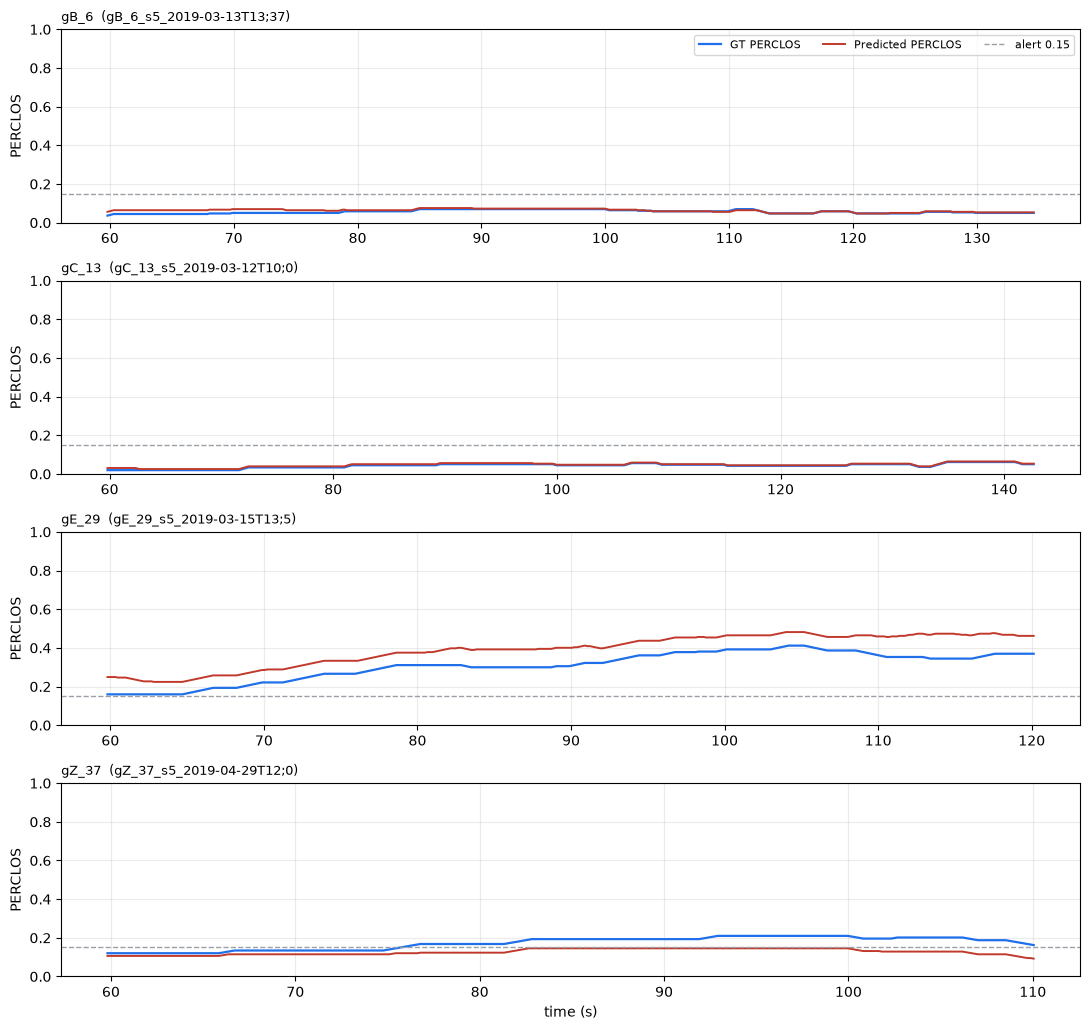

subject  perclos_mae  gt_mean  pred_mean
   gB_6       0.0066   0.0566     0.0627
  gC_13       0.0043   0.0425     0.0467
  gE_29       0.0812   0.3080     0.3891
  gZ_37       0.0448   0.1722     0.1275


In [5]:
# [셀 5] PERCLOS 곡선 대조 (그림)
import matplotlib
import matplotlib.pyplot as plt

WINDOW_SEC = 60.0          # PERCLOS 창. STEP03 의 기본값과 같게 둔다

def perclos_curve(d, window_sec, fps, stride):
    """이동창 PERCLOS. 분모는 '판정 가능한 프레임'이다 (결정 박스 10)."""
    step_sec = stride / fps if fps else 1 / 25 * stride
    w = max(1, int(round(window_sec / step_sec)))
    ok = d.face_ok.values.astype(float)
    gt = (d.gt_binary.values == 1).astype(float) * ok
    pr = np.nan_to_num((d.p_closed.values >= THRESHOLD).astype(float)) * ok
    num_ok = pd.Series(ok).rolling(w, min_periods=w).sum().values
    with np.errstate(invalid="ignore", divide="ignore"):
        g = pd.Series(gt).rolling(w, min_periods=w).sum().values / num_ok
        p = pd.Series(pr).rolling(w, min_periods=w).sum().values / num_ok
    t = np.arange(len(d)) * step_sec
    return t, g, p

fig, axes = plt.subplots(len(preds), 1, figsize=(11, 2.6 * len(preds)), sharex=False)
axes = np.atleast_1d(axes)
mae_rows = []

for ax, (base, d) in zip(axes, preds.items()):
    fps = float(d.fps.iloc[0]) or 25.0
    t, g, p = perclos_curve(d, WINDOW_SEC, fps, STRIDE)
    ax.plot(t, g, lw=1.6, color="#1f6feb", label="GT PERCLOS")
    ax.plot(t, p, lw=1.4, color="#c0392b", label="Predicted PERCLOS")
    ax.axhline(0.15, ls="--", lw=1, color="#9aa0a6", label="alert 0.15")
    ax.set_ylim(0, 1)
    ax.set_ylabel("PERCLOS")
    ax.set_title(f"{d.subject.iloc[0]}  ({base[:24]})", fontsize=9, loc="left")
    ax.grid(alpha=0.25)
    valid = ~(np.isnan(g) | np.isnan(p))
    mae_rows.append(dict(subject=d.subject.iloc[0],
                         perclos_mae=round(float(np.abs(g[valid] - p[valid]).mean()), 4),
                         gt_mean=round(float(np.nanmean(g)), 4),
                         pred_mean=round(float(np.nanmean(p)), 4)))

axes[0].legend(fontsize=8, ncol=3, loc="upper right")
axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.savefig(OUT_DIR / "perclos_curves.png", dpi=130)
plt.show()

print(pd.DataFrame(mae_rows).to_string(index=False))

### PERCLOS 결과

- PERCLOS MAE: gC_13 0.0043, gB_6 0.0066, gZ_37 0.0448, gE_29 0.0812
- gZ_37은 평균 PERCLOS가 **0.1722 → 0.1275**로 낮아졌다.
- 임계값 0.15에서 gZ_37만 GT와 예측의 구간 판정이 달랐다.
- 나머지 세 subject는 GT와 예측이 같은 쪽이었다.


In [6]:
# [셀 6] 최장 연속 감김 (microsleep 후보)
def longest_closed_sec(flags, fps, stride):
    """연속 Closed 판정의 최장 지속 시간(초). 프레임 수가 아니라 시간으로 잰다."""
    step = stride / fps if fps else stride / 25.0
    best = cur = 0
    for v in flags:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return round(best * step, 2)

rows = []
for base, d in preds.items():
    fps = float(d.fps.iloc[0]) or 25.0
    gt_flag = (d.gt_binary.values == 1)
    pr_flag = np.nan_to_num(d.p_closed.values) >= THRESHOLD
    rows.append(dict(subject=d.subject.iloc[0],
                     gt_longest_sec=longest_closed_sec(gt_flag, fps, STRIDE),
                     pred_longest_sec=longest_closed_sec(pr_flag, fps, STRIDE)))

ms = pd.DataFrame(rows)
ms["diff_sec"] = (ms.pred_longest_sec - ms.gt_longest_sec).round(2)
print(ms.to_string(index=False))
print("\nmicrosleep 후보 기준은 문헌마다 다르다. 여기서는 기준을 정하지 않고 "
      "GT 와 예측의 최장 지속 시간만 비교한다.")

subject  gt_longest_sec  pred_longest_sec  diff_sec
   gB_6            1.34              1.01     -0.33
  gC_13            1.51              1.51      0.00
  gE_29            2.69              2.69      0.00
  gZ_37            2.35              2.02     -0.33

microsleep 후보 기준은 문헌마다 다르다. 여기서는 기준을 정하지 않고 GT 와 예측의 최장 지속 시간만 비교한다.


### 최장 감김 결과

- GT는 1.34~2.69초, 예측은 1.01~2.69초였다.
- subject별 차이는 0.00초 또는 −0.33초였다.


## PART C — 연결 판단

### 목적

- STEP03(YuNet 실시간 추론)의 Eye CNN 을 이 모델로 교체할 수 있는지 판단한다.
- STEP03 은 수정 금지 대상이므로 판단 기준은 "코드를 고치지 않고 로드되는가" 하나다.

In [7]:
# [셀 7] STEP03 교체 가능성 점검
_step03_model = config.ARTIFACT_DIR / "eye_model.keras"
_ok_shape = None
if _step03_model.exists():
    _ref = tf.keras.models.load_model(_step03_model)
    _ok_shape = tuple(_ref.input_shape[1:])

_cur = tuple(eye_model.input_shape[1:])
print("STEP03 이 로드하는 모델 입력 :", _ok_shape)
print("이 노트북에서 평가한 모델 입력 :", _cur)
print("입력 규격 일치 :", _ok_shape == _cur)
print()
print("판단 기준")
print("  - 규격이 일치하면 eye_model.keras 를 교체하는 것만으로 STEP03 이 새 모델을 쓴다.")
print("  - 일치하지 않으면 STEP03 을 고쳐야 하는데 수정 금지 대상이므로 교체할 수 없다.")
print("    이 경우 선택지는 두 가지다.")
print("      1) 같은 규격(256 RGB)으로 재학습한 부록 모델을 쓴다.")
print("      2) STEP03 을 대체하는 별도 실시간 노트북을 새로 만든다.")
print()
print("성능 근거는 셀 4 의 Closed-Recall 과 판정 불가 비율, 셀 5 의 PERCLOS MAE 다.")
print("규격이 맞더라도 이 수치가 기존 모델보다 낫다는 확인 없이 교체하지 않는다.")

STEP03 이 로드하는 모델 입력 : (256, 256, 3)
이 노트북에서 평가한 모델 입력 : (128, 128, 1)
입력 규격 일치 : False

판단 기준
  - 규격이 일치하면 eye_model.keras 를 교체하는 것만으로 STEP03 이 새 모델을 쓴다.
  - 일치하지 않으면 STEP03 을 고쳐야 하는데 수정 금지 대상이므로 교체할 수 없다.
    이 경우 선택지는 두 가지다.
      1) 같은 규격(256 RGB)으로 재학습한 부록 모델을 쓴다.
      2) STEP03 을 대체하는 별도 실시간 노트북을 새로 만든다.

성능 근거는 셀 4 의 Closed-Recall 과 판정 불가 비율, 셀 5 의 PERCLOS MAE 다.
규격이 맞더라도 이 수치가 기존 모델보다 낫다는 확인 없이 교체하지 않는다.


### STEP03 연결 확인

STEP03 입력은 `(256, 256, 3)`, 현재 모델은 `(128, 128, 1)`이므로 바로 교체할 수 없다.


## 해석

- 이번 DMD test에서는 원본 영상 파이프라인과 저장된 crop 평가의 Recall이 비슷했다.
- 얼굴 검출 실패가 없어 YuNet의 실패 영향을 따로 평가하지 못했다.
- gZ_37의 낮은 Recall은 PERCLOS에도 반영됐다.
- subject가 4명뿐이므로 개인별 차이의 원인은 판단할 수 없다.


## 한계

- test는 4명이며 모두 `Car Stopped` 조건이다.
- gZ_37의 성능 저하 원인은 확인하지 못했다.
- PERCLOS 0.15는 이 데이터에서 정한 임계값이 아니다.
- 얼굴 검출 실패가 있는 영상은 평가하지 못했다.


## STEP13 요약

- DMD 원본 영상 파이프라인: Recall **0.9159**, F1 **0.8529**
- gZ_37 Recall은 **0.6860**, PERCLOS는 **0.1722 → 0.1275**였다.
- 이 결과는 4명의 정차 영상에 한정된다.
